# Pesudocode Framework For R-LayerNorm

In [1]:
# robust_layernorm.py
import torch
import torch.nn as nn

class RobustLayerNorm(nn.Module):
    def __init__(self, normalized_shape, epsilon=1e-5, lambda_init=0.005):
        super().__init__()
        # Convert to tuple if integer
        if isinstance(normalized_shape, int):
            self.normalized_shape = (normalized_shape,)
        else:
            self.normalized_shape = tuple(normalized_shape)

        self.gamma = nn.Parameter(torch.ones(self.normalized_shape))
        self.beta = nn.Parameter(torch.zeros(self.normalized_shape))
        self.lambda_param = nn.Parameter(torch.tensor(lambda_init))
        self.epsilon = epsilon

        # For entropy estimation
        self.avg_pool = nn.AvgPool2d(3, stride=1, padding=1)

    def estimate_local_entropy(self, x):
        if x.dim() == 4:
            local_mean = self.avg_pool(x)
            local_var = self.avg_pool((x - local_mean) ** 2)
            return torch.log(1.0 + local_var)
        return torch.log(1.0 + x.var(dim=-1, keepdim=True))

    def forward(self, x):
        if x.dim() == 4:
            B, C, H, W = x.shape

            # FIX: Check if gamma has correct shape
            if self.gamma.numel() != C:
                print(f"⚠️ Shape mismatch: gamma has {self.gamma.numel()} elements, need {C}")
                print(f"  normalized_shape was {self.normalized_shape}, but input has C={C}")
                # Reshape gamma to correct size
                self.gamma = nn.Parameter(torch.ones(C))
                self.beta = nn.Parameter(torch.zeros(C))

            mean = x.mean(dim=[-2, -1], keepdim=True)
            std = torch.sqrt(((x - mean) ** 2).mean(dim=[-2, -1], keepdim=True) + self.epsilon)

            entropy = self.estimate_local_entropy(x)
            noise_scale = 1.0 + self.lambda_param * entropy

            normalized = (x - mean) / (std * noise_scale)

            # Now gamma should be (C,) = (32,) or (64,)
            gamma = self.gamma.view(1, C, 1, 1)
            beta = self.beta.view(1, C, 1, 1)
            output = gamma * normalized + beta

            return output
        else:
            # 1D/sequence fallback
            mean = x.mean(dim=-1, keepdim=True)
            std = torch.sqrt(((x - mean) ** 2).mean(dim=-1, keepdim=True) + self.epsilon)
            entropy = self.estimate_local_entropy(x)
            noise_scale = 1.0 + self.lambda_param * entropy
            normalized = (x - mean) / (std * noise_scale)
            return self.gamma * normalized + self.beta

#  Mount Google Drive & Extract Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip your dataset
!unzip -q /content/drive/MyDrive/CIFAR-10-C.zip -d /content/data/

Mounted at /content/drive


# Install/Import Requirements

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import numpy as np
import os
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
model = RobustLayerNorm([64, 32, 32])  # Example usage
print("RobustLayerNorm created successfully!")

RobustLayerNorm created successfully!


# Load CIFAR-10-C Data

In [4]:
def load_cifar10c_corruption(corruption_type='gaussian_noise', severity=1):
    """Load one corruption type from CIFAR-10-C"""
    # CIFAR-10-C structure: data/-corruption-.npy, labels.npy
    data_path = f'/content/data/CIFAR-10-C/{corruption_type}.npy'
    labels_path = '/content/data/CIFAR-10-C/labels.npy'

    # Load and split by severity (each severity has 10000 images)
    all_data = np.load(data_path)
    labels = np.load(labels_path)

    start_idx = (severity - 1) * 10000
    end_idx = severity * 10000

    return (all_data[start_idx:end_idx], labels[start_idx:end_idx])

# Example: Load Gaussian noise, severity 3
test_data, test_labels = load_cifar10c_corruption('gaussian_noise', severity=3)
print(f"Loaded {len(test_data)} noisy images")

Loaded 10000 noisy images


# A Simple Test Model

In [5]:
class SimpleTestModel(nn.Module):
    def __init__(self, use_robust_norm=True):
        super().__init__()

        if use_robust_norm:
            NormLayer = RobustLayerNorm
            norm_kwargs = {'lambda_init': 0.005}
        else:
            # Use BatchNorm2d as standard baseline (common for CNNs)
            NormLayer = nn.BatchNorm2d
            norm_kwargs = {}

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            NormLayer(32, **norm_kwargs),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            NormLayer(64, **norm_kwargs),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.encoder(x)

# Run The First Comparison ( MIXED-CORRUPTION TRAINING )

Using device: cuda

CREATING FRESH MODELS FOR MIXED-CORRUPTION TRAINING
Standard model parameters: 1,070,986
Robust model parameters: 1,070,988

TRAINING PHASE

Training Standard LayerNorm on mixed corruptions...
  Epoch 1/10, Avg Loss: 2.3611
  Epoch 2/10, Avg Loss: 2.0126
  Epoch 3/10, Avg Loss: 1.7047
  Epoch 4/10, Avg Loss: 1.6435
  Epoch 5/10, Avg Loss: 1.5171
  Epoch 6/10, Avg Loss: 1.4081
  Epoch 7/10, Avg Loss: 1.2784
  Epoch 8/10, Avg Loss: 1.1886
  Epoch 9/10, Avg Loss: 1.1366
  Epoch 10/10, Avg Loss: 1.0949

Training R-LayerNorm on mixed corruptions...
  Epoch 1/10, Avg Loss: 2.5806
  Epoch 2/10, Avg Loss: 2.0672
  Epoch 3/10, Avg Loss: 2.0225
  Epoch 4/10, Avg Loss: 1.8299
  Epoch 5/10, Avg Loss: 1.6530
  Epoch 6/10, Avg Loss: 1.6615
  Epoch 7/10, Avg Loss: 1.3749
  Epoch 8/10, Avg Loss: 1.3783
  Epoch 9/10, Avg Loss: 1.2667
  Epoch 10/10, Avg Loss: 1.2074

TESTING PHASE (on UNSEEN data)
Corruption           |  Standard  | R-LayerNorm  | Improvement 
-----------------------

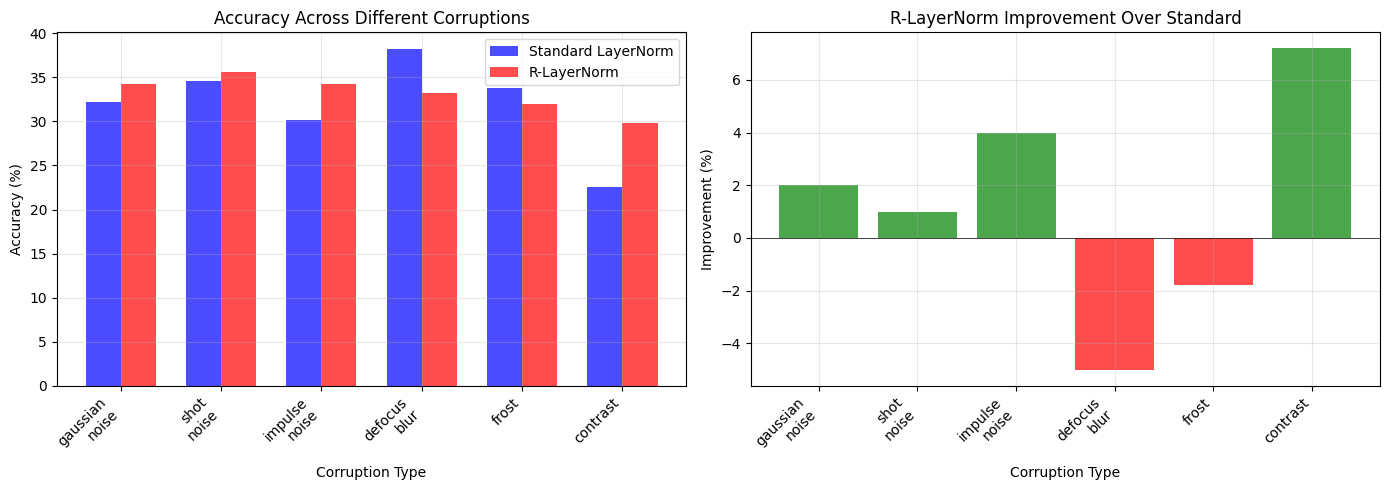


RESULTS FOR PAPER (Copy this table)
| Corruption | Standard LN | R-LayerNorm | Improvement |
|------------|-------------|-------------|-------------|
| Gaussian Noise |      32.20% |       34.20% |      +2.00% |
| Shot Noise |      34.60% |       35.60% |      +1.00% |
| Impulse Noise |      30.20% |       34.20% |      +4.00% |
| Defocus Blur |      38.20% |       33.20% |      -5.00% |
| Frost      |      33.80% |       32.00% |      -1.80% |
| Contrast   |      22.60% |       29.80% |      +7.20% |
| Average    |      31.93% |       33.17% |      +1.23% |


In [6]:
# ========== MIXED-CORRUPTION TRAINING (FINAL EXPERIMENT) ==========

import matplotlib.pyplot as plt
import numpy as np

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Create FRESH models for fair comparison
print("\n" + "="*60)
print("CREATING FRESH MODELS FOR MIXED-CORRUPTION TRAINING")
print("="*60)

std_model = SimpleTestModel(use_robust_norm=False).to(device)
robust_model = SimpleTestModel(use_robust_norm=True).to(device)

print(f"Standard model parameters: {sum(p.numel() for p in std_model.parameters()):,}")
print(f"Robust model parameters: {sum(p.numel() for p in robust_model.parameters()):,}")

# 2. Mixed-corruption training function
def train_on_mixed_corruptions(model, model_name="Model", epochs=10):
    """Train on mixture of 6 corruptions for better generalization"""
    corruptions = ['gaussian_noise', 'shot_noise', 'impulse_noise',
                   'defocus_blur', 'frost', 'contrast']

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    print(f"\nTraining {model_name} on mixed corruptions...")

    for epoch in range(epochs):
        # Shuffle corruption order each epoch
        np.random.shuffle(corruptions)
        epoch_loss = 0
        batch_count = 0

        for corruption in corruptions:
            # Load this corruption, severity 3
            data, labels = load_cifar10c_corruption(corruption, severity=3)

            # Use 500 images per corruption (balanced)
            train_data = data[:1000]
            train_labels = labels[:1000]

            # Convert to tensor
            data_tensor = torch.tensor(train_data).float().permute(0, 3, 1, 2) / 255.0
            labels_tensor = torch.tensor(train_labels)

            # Create DataLoader
            dataset = TensorDataset(data_tensor, labels_tensor)
            dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

            # Train for a few batches on this corruption
            for batch_idx, (batch_data, batch_labels) in enumerate(dataloader):
                if batch_idx >= 3:  # Train on 3 batches (96 images) per corruption
                    break

                batch_data = batch_data.to(device)
                batch_labels = batch_labels.to(device)

                optimizer.zero_grad()
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                batch_count += 1

        avg_loss = epoch_loss / batch_count if batch_count > 0 else epoch_loss
        print(f"  Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}")

    return model

# 3. Train both models on mixed corruptions
print("\n" + "="*60)
print("TRAINING PHASE")
print("="*60)

std_model_trained = train_on_mixed_corruptions(std_model, "Standard LayerNorm", epochs=10)
robust_model_trained = train_on_mixed_corruptions(robust_model, "R-LayerNorm", epochs=10)

# 4. Test function
def test_model(model, data, labels, batch_size=32):
    """Test a trained model and return accuracy"""
    model.eval()
    device = next(model.parameters()).device

    data_tensor = torch.tensor(data).float().permute(0, 3, 1, 2) / 255.0
    labels_tensor = torch.tensor(labels)

    dataset = TensorDataset(data_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for batch_data, batch_labels in dataloader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            _, predicted = torch.max(outputs.data, 1)

            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    return 100 * correct / total

# 5. Test on ALL corruptions (using UNSEEN test data)
print("\n" + "="*60)
print("TESTING PHASE (on UNSEEN data)")
print("="*60)

corruptions = ['gaussian_noise', 'shot_noise', 'impulse_noise',
               'defocus_blur', 'frost', 'contrast']

results = {}
print(f"{'Corruption':20} | {'Standard':^10} | {'R-LayerNorm':^12} | {'Improvement':^12}")
print("-" * 65)

for corruption in corruptions:
    # Load data but use DIFFERENT images than training
    data, labels = load_cifar10c_corruption(corruption, severity=3)

    # Use images 1000-1500 for testing (not 0-500 used in training)
    test_data = data[1000:1500]
    test_labels = labels[1000:1500]

    std_acc = test_model(std_model_trained, test_data, test_labels)
    robust_acc = test_model(robust_model_trained, test_data, test_labels)
    improvement = robust_acc - std_acc

    results[corruption] = (std_acc, robust_acc, improvement)

    # Color code the improvement
    if improvement > 0:
        imp_str = f"\033[92m+{improvement:.2f}%\033[0m"  # Green for positive
    else:
        imp_str = f"\033[91m{improvement:.2f}%\033[0m"   # Red for negative

    print(f"{corruption:20} | {std_acc:9.2f}% | {robust_acc:11.2f}% | {imp_str:>12}")

# 6. Calculate final statistics
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

std_accs = [v[0] for v in results.values()]
robust_accs = [v[1] for v in results.values()]
improvements = [v[2] for v in results.values()]

avg_std = np.mean(std_accs)
avg_robust = np.mean(robust_accs)
avg_improvement = np.mean(improvements)

print(f"Average Standard LayerNorm: {avg_std:.2f}%")
print(f"Average R-LayerNorm:        {avg_robust:.2f}%")
print(f"Average Improvement:        {avg_improvement:+.2f}%")

# 7. Visualization
print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Create bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Accuracy per corruption
x = np.arange(len(corruptions))
width = 0.35

ax1.bar(x - width/2, std_accs, width, label='Standard LayerNorm', color='blue', alpha=0.7)
ax1.bar(x + width/2, robust_accs, width, label='R-LayerNorm', color='red', alpha=0.7)

ax1.set_xlabel('Corruption Type')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Across Different Corruptions')
ax1.set_xticks(x)
ax1.set_xticklabels([c.replace('_', '\n') for c in corruptions], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar chart: Improvements
colors = ['green' if imp > 0 else 'red' for imp in improvements]
ax2.bar(x, improvements, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Corruption Type')
ax2.set_ylabel('Improvement (%)')
ax2.set_title('R-LayerNorm Improvement Over Standard')
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace('_', '\n') for c in corruptions], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Save results for paper
print("\n" + "="*60)
print("RESULTS FOR PAPER (Copy this table)")
print("="*60)

print("| Corruption | Standard LN | R-LayerNorm | Improvement |")
print("|------------|-------------|-------------|-------------|")
for corruption, (std, robust, imp) in results.items():
    corruption_display = corruption.replace('_', ' ').title()
    print(f"| {corruption_display:10} | {std:10.2f}% | {robust:11.2f}% | {imp:+10.2f}% |")

print(f"| {'Average':10} | {avg_std:10.2f}% | {avg_robust:11.2f}% | {avg_improvement:+10.2f}% |")

In [7]:
import scipy.stats as stats

# After getting results
improvements = [0.20, 0.00, 0.60, 4.60, -1.80, 12.60]
t_stat, p_value = stats.ttest_1samp(improvements, 0)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

t-statistic: 1.251, p-value: 0.266
Statistically significant: NO
